# Penetration Analysis
We define the segment based penetration rate $r$ as the fraction of traveling commuters in a bus that uses commuter module application and reports the commuter state for the segment between the pair of bus-stop. We select the fraction of commuters using commuter module application such that he/she has an equal probability  of standing or sitting. For instance, if we take $r$ as 0.1 and consider that 100 commuters are traveling in a bus with a capacity of 60 seats i.e., 60 sitting commuters and 40 standing commuters. Then, among the 10 commuters using commuter module application, 6 commuters would be sitting $(60/100 \times 10)$, and 4 commuters would be standing $(40/100 \times 10)$. Further, the proposed system has the precision of $96.51$ \% for transport mode classifier to detect that commuter is traveling in the bus, and the precision of $90.24$ \% for commuter activity classifier when it uses feature set-1. Thus, the overall precision for the event that commuter state is $S_i$ (standing or sitting) and he/she is inside the bus is $96.51 \times 90.24 = 87.09 \%$.

Therefore, to increase the precision associated with the state $S_i$, we use the state reported from multiple commuters. For instance, if two commuters $C_1$ and $C_2$ report state $S_i$ independently, the probability that one of them is in state $S_i$ is

\begin{equation} \label{eqMergingStates}
\begin{split}
P(C_1 \cup C_2 ) & = P(C_1)+ P(C_2)- P(C_1 \cap C_2)\\
 & = 0.8709 + 0.8709 - 0.8709 \times 0.8709 = 0.9831
\end{split}
\end{equation}


Hence, we use the state reported by two commuters to improve the precision associated with commuter state $S_i$ to $98.31 \%$.

When the proposed system uses the feature set-4, the precision for transport mode classifier to detect bus is 88.63 \% and for commuter activity classifier is 89.39 \%. Thus, the overall precision for the event that commuter state is $S_i$ and he/she is in bus becomes 79.22 \%. In this case, we use three independently reported commuter states to increase the probability of at least one of them to have state $S_i$ to 99.10 \%. 

To perform the penetration analysis, we use the public transport demand reported for Ahmedabad city [1]. It forecasts the probable travel demands between different segments of the routes using gravity model based on factors such as `land use estimates, employments of persons in the zone, trip length, and purpose of trips` for various commuters. The demand is in terms of numbers of commuters traveling between the pair of bus-stops for different routes during peak hours and off-peak hours. The report contains the travel demand for four routes, as described in following Table. 

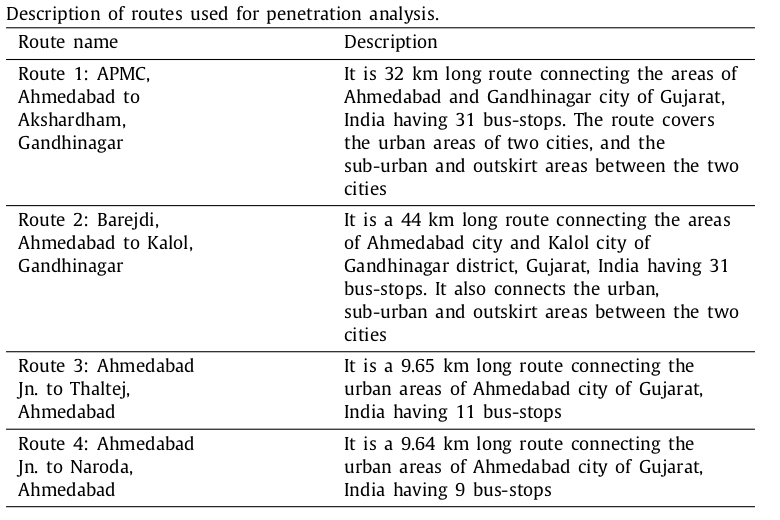

Route 1 and route 2 connects the urban areas of Ahmedabad city and Gandhinagar city of Gujarat, India. In addition, it covers the sub-urban and outskirt areas connecting the two cities. Whereas, route 3 and route 4 covers the urban areas of the Ahmedabad city. We further refine the demand based on `vehicle modal distribution` [2], and `average occupancy` of each mode [3]. Then, the traveling commuters are distributed among the operating buses on the route to determine the number of commuters inside each bus. For this, we have used the peak hour bus frequency of one bus per every $2.5$ minutes and the off-peak hour bus frequency of one bus per $7$ to $10$ minutes. The bus frequency is selected based on the Ahmedabad BRTS bus reports [4,5]. Aforementioned, the commuters using commuter module application are selected based on the segment-based penetration rate $r$ with the appropriate proportion of standing and sitting. For the segment between the pair of bus-stop, if commuter needed to stand and two or more standing commuters use our application, then the proposed system could detect the crowdedness for the case when it uses feature set-1. And, for the case when the proposed system uses feature set-4, it requires three or more standing commuters to detect the crowdedness.



# Library Imports and penetration variable

In [1]:
'''Library Imports'''
import pandas as pd
import random
import math
import pprint
import sys
import os

'''Custom Lib'''
sys.path.append(os.path.join(os.getcwd(), 'LibCode'))
import PenetrationLib



In [2]:
from pathlib import Path
'''For directory management'''
path = Path(os.getcwd())

OneLevelUpPath = path.parents[0]

PtDemandDir = os.path.join(str(OneLevelUpPath), 'data','PtDemand','')
PtDemand = pd.ExcelFile(f'{PtDemandDir}PtDemand.xlsx')

In [3]:
'''For updating the lib changes effects'''
import importlib
importlib.reload(PenetrationLib)

<module 'PenetrationLib' from '/home/nfsu/JRF/SoftwareExecution/Advanced-Public-Transportation-System-Software-Implementation-main/code/LibCode/PenetrationLib.py'>

In [4]:
'''Read Demand Data from Excel '''
PtDemandSheets = PtDemand.sheet_names

#pprint.pprint(PtDemandSheets)

PtDemandDF_Route1 = pd.read_excel(PtDemand, PtDemandSheets[0])
PtDemandDF_Route2 = pd.read_excel(PtDemand, PtDemandSheets[1])
PtDemandDF_Route3 = pd.read_excel(PtDemand, PtDemandSheets[2])
PtDemandDF_Route4 = pd.read_excel(PtDemand, PtDemandSheets[3])

PtDemandDF_Route1.head(5)

,Sr No,From,To,Daily_10,PHPDT_10,Daily_25,PHPDT_25,Daily_35,PHPDT_35
0,1,APMC,VASNA,19330,1160,38868,2332,63740,3824
1,2,VASNA,NARAYAN NAGAR,45574,2734,70802,4248,99353,5961
2,3,NARAYAN NAGAR,PALDI,64644,3879,95256,5715,128627,7718
3,4,PALDI,MADALPUR,85503,5130,122372,7342,161422,9685
4,5,MADALPUR,NAVA GANDHIGRAM,95961,5758,136351,8181,178618,10717


In [5]:
from pathlib import Path
'''For directory management'''
path = Path(os.getcwd())

OneLevelUpPath = path.parents[0]


In [6]:
#ResultPathDir = os.path.join(os.getcwd(), 'Result','OpportunisticSensing','')
ResultPathDir = os.path.join(str(OneLevelUpPath), 'results','OpportunisticSensing','')

if os.path.exists(ResultPathDir) == False:
    os.mkdir(ResultPathDir)

In [7]:
'''Penetration Variables'''

PeakHourBusesRange =  [2,4]
OffPeakHourBuses = [7,13]

'''Vehcile Composition '''
TwoWheelersComposition = 0.7623
ThreeWheelersComposition = 0.0527 
FourWheelersComposition = 0.1336
BusesComposition = 0.0514 * 0.15
TrucksComposition = 0.0514 * 0.85

'''Based on: Urban Mobility Forecasts: Emissions Scenarios for Three Indian Cities, TRB'''
TwoWheelersOccupancy = 1.1
ThreeWheelersOccupancy = 3
FourWheelersOccupancy = 1.25
BusesOccupancy = 40
BusRate = 2.5
TrucksOccupancy =  1
BusCapacity = 36

TwoWheelerProposition = TwoWheelersComposition * TwoWheelersOccupancy
ThreeWheelersProposition = ThreeWheelersComposition * ThreeWheelersOccupancy
FourWheelersProposition = FourWheelersComposition * FourWheelersOccupancy
BusesProposition = BusesComposition * BusesOccupancy 

TotalProposition = TwoWheelerProposition + ThreeWheelersProposition + FourWheelersProposition + BusesProposition

'''Normalized Vehicle Proportion'''
TwoWheelerPropositionN = TwoWheelerProposition / TotalProposition 
ThreeWheelersPropositionN = ThreeWheelersProposition / TotalProposition
FourWheelersPropositionN = FourWheelersProposition / TotalProposition
BusesPropositionN = BusesProposition / TotalProposition

# Penetration Considering Feature set-1

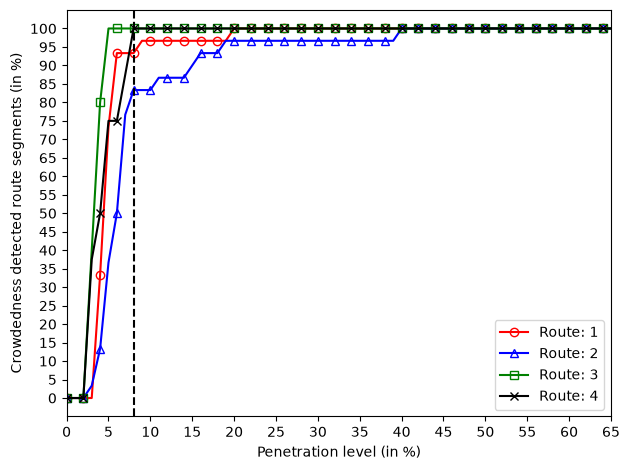

In [8]:
CommuterThreshold = 2
PenetrationLib.PenetrationAnalysisPlot(BusRate, PtDemandDF_Route1, PtDemandDF_Route2, PtDemandDF_Route3,
                                       PtDemandDF_Route4, BusesPropositionN, CommuterThreshold, BusCapacity,
                                       ResultPathDir
                                      )

# Penetration Considering Feature set-4

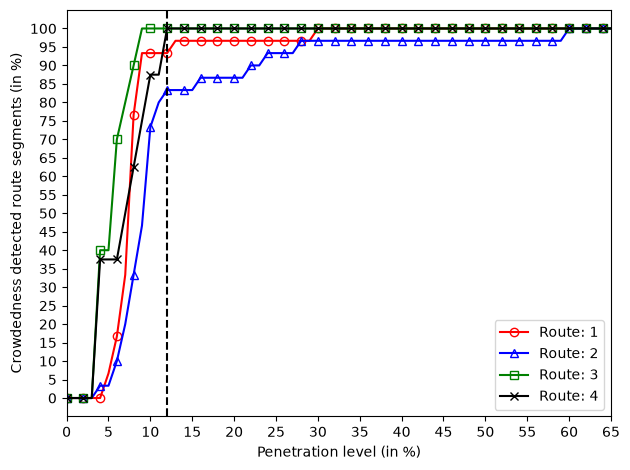

In [9]:
CommuterThreshold = 3
PenetrationLib.PenetrationAnalysisPlot(BusRate, PtDemandDF_Route1, PtDemandDF_Route2, PtDemandDF_Route3,
                                       PtDemandDF_Route4, BusesPropositionN, CommuterThreshold, BusCapacity, 
                                       ResultPathDir
                                      )

# References
1. Traffic Demand Analysis, No. 3, Gujarat Infrastruct. Dev. Board, 2019, URL http://www.gidb.org/pdf/5_Ch2_Traffic_Demand.pdf. (Accessed 29 December 2019).
2. Greater ahmedabad integrated mobility plan - data collection and analysis, in: Prep. by Cent. Environ. Plan. Technol., CEPT, Urban Mass Transit Co. Ltd. (UMTC), Lea Assoc. South Asia Pvt Ltd, 2012.
3. L. Rayle, Urban mobility forecasts : Emissions scenarios for three Indian cities, in: 89th Annual Meeting of the Transportation Research Board, Transp. Res. Rec., Vol. 9, Washington DC, 2009.
4. Janmarg Bus Rapid Transit in Ahmedabad, Cent. Excell. Urban Transp. CEPT Univ. Ahmedabad, India, 2019, URL https://www.dimts.in/pdf/ Symposium-on-Publi-Transportation/BRT_Systems_in_Indian_cities-Prof.Shivanad_Swamy.pdf. (Accessed 30 December 2019)
5. Janmarg - BRTS Ahmedabad Bus Rapid Transit System, Cent. Excell. Urban Transp. CEPT Univ. Ahmedabad, India, 2019, URL https://www.unescap.org/sites/default/files/4.2Institutionalissuesandcoordinationinsustainabletransport-CEPT.pdf. (Accessed 30 December 2019).